In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
import pickle
plt.style.use(['science','no-latex'])
colors = ["#1982c4", "black", "#ff595e", "#20b806"]

In [2]:
def plot_free_energy(XDATA, YDATA, xlabel, ylabel, bins=20):
    temperature = 1.
    values, xedge, yedge = np.histogram2d(XDATA, YDATA, bins=bins)
    xs = xedge[:-1] + (xedge[1] - xedge[0]) / 2  # Calculate the center of each bin
    ys = yedge[:-1] + (yedge[1] - yedge[0]) / 2  # Calculate the center of each bin
    total = np.sum(values)
    values = values / total
    values_nan = np.where(values == 0, np.nan, values)
    free_ene = -np.log(values_nan) / temperature

    X, Y = np.meshgrid(xs, ys)
    plt.contourf(X, Y, free_ene.T, cmap='YlGnBu')
    plt.colorbar(label='free energy (KBT)')
    plt.contour(X, Y, free_ene.T, colors='k', linewidths=1)
    plt.plot(np.linspace(0, np.pi, 2), np.linspace(0, np.pi, 2),  "--", color="black")
    plt.xlim([0, np.pi])
    plt.ylim([0, np.pi])
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title('Free energy landscape')
    #plt.savefig('./images/long_simulation_st.png', transparent=True)
    plt.show()

def compute_IGs(imbalances, correction=True):    
    n_indep_realizations = imbalances.shape[0]
    n_taus = imbalances.shape[1]
    
    IGs_vs_alpha = 100*(imbalances[:,:,0,np.newaxis]-imbalances) / imbalances[:,:,0,np.newaxis]
    alphas_max = np.argmax(IGs_vs_alpha.mean(axis=0), axis=-1)

    IGs = IGs_vs_alpha.mean(axis=0)[np.arange(n_taus),alphas_max]
    errors = IGs_vs_alpha.std(axis=0)[np.arange(n_taus),alphas_max] / np.sqrt(n_indep_realizations)

    if correction:
        IGs[imbalances[:,:,0].mean(axis=0) > 1] = 0
        errors[imbalances[:,:,0].mean(axis=0) > 1] = 0
        
    return IGs, errors

In [9]:
dir = "/scratch/vdeltatt/imbalance-gain-causality/langevin"

# 1) Asymmetric wells

### 1.3.2) Transfer entropy with inset for small taus, knncmi estimator, inset

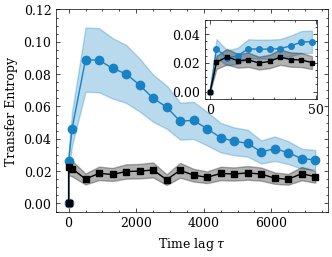

In [52]:
dir = '/scratch/vdeltatt/imbalance-gain-causality/langevin'
plt.rcParams.update({'font.size': 9})

k = 7
N = 2500
taus = np.arange(10,770,40,dtype=int) * 10 # large taus are 100 times larger than small taus
taus_small = np.append([0], np.arange(5, 505, 25,dtype=int) / 10)
seeds = np.arange(20)

TEs_X_to_Y = np.zeros((len(seeds),len(taus)))
TEs_Y_to_X = np.zeros((len(seeds),len(taus)))
TEs_X_to_Y_small = np.zeros((len(seeds),len(taus_small)-1))
TEs_Y_to_X_small = np.zeros((len(seeds),len(taus_small)-1))

for iseed, seed in enumerate(seeds):
    _, TEs_X_to_Y[iseed], TEs_Y_to_X[iseed], _, _ = (
        pickle.load(open(dir + f"/asymmetric_energy_far/pickles_te/seed{seed}_N{N}_k{k}.p","rb"))
    )
    _, TEs_X_to_Y_small[iseed], TEs_Y_to_X_small[iseed], _, _ = (
        pickle.load(open(dir + f"/asymmetric_energy_far/small_lags/pickles_te/seed{seed}_N{N}_k{k}.p","rb"))
    )

# discrete
avg_X_to_Y, err_X_to_Y = TEs_X_to_Y.mean(axis=0), TEs_X_to_Y.mean(axis=0) / np.sqrt(TEs_X_to_Y.shape[0])
avg_Y_to_X, err_Y_to_X = TEs_Y_to_X.mean(axis=0), TEs_Y_to_X.mean(axis=0) / np.sqrt(TEs_Y_to_X.shape[0])
# inset
subsamples = np.arange(0,len(taus_small),2)
avg_X_to_Y_small, err_X_to_Y_small = TEs_X_to_Y_small.mean(axis=0), TEs_X_to_Y_small.mean(axis=0) / np.sqrt(TEs_X_to_Y_small.shape[0])
avg_Y_to_X_small, err_Y_to_X_small = TEs_Y_to_X_small.mean(axis=0), TEs_Y_to_X_small.mean(axis=0) / np.sqrt(TEs_Y_to_X_small.shape[0])
avg_X_to_Y_small = np.append([0],avg_X_to_Y_small)
avg_Y_to_X_small = np.append([0],avg_Y_to_X_small)
err_X_to_Y_small = np.append([0],err_X_to_Y_small)
err_Y_to_X_small = np.append([0],err_Y_to_X_small)

fig, ax1 = plt.subplots()
extended_taus = np.append(taus_small[0:2], taus)
extended_avg_X_to_Y = np.concatenate((avg_X_to_Y_small[0:2], avg_X_to_Y))
extended_avg_Y_to_X = np.concatenate((avg_Y_to_X_small[0:2], avg_Y_to_X))
extended_err_X_to_Y = np.concatenate((err_X_to_Y_small[0:2], err_X_to_Y))
extended_err_Y_to_X = np.concatenate((err_Y_to_X_small[0:2], err_Y_to_X))
ax1.plot(extended_taus, extended_avg_X_to_Y, 'o-', color=colors[0])
ax1.plot(extended_taus, extended_avg_Y_to_X, 's-', color=colors[1], markersize=5)
ax1.fill_between(extended_taus, extended_avg_X_to_Y-extended_err_X_to_Y, extended_avg_X_to_Y+extended_err_X_to_Y, alpha=0.3, color=colors[0])
ax1.fill_between(extended_taus, extended_avg_Y_to_X-extended_err_Y_to_X, extended_avg_Y_to_X+extended_err_Y_to_X, alpha=0.3, color=colors[1])
#plt.hlines(0.0, taus[0], taus[-1], linestyle="--", color="black")
ax1.set(ylim=[-0.005,0.12])
plt.xlabel("Time lag $\\tau$")
plt.ylabel("Transfer Entropy")

ax2 = fig.add_axes([0.55, 0.54, 0.32, 0.3])
plt.plot(taus_small[subsamples], avg_X_to_Y_small[subsamples], 'o-', color=colors[0], markersize=4)
plt.plot(taus_small[subsamples], avg_Y_to_X_small[subsamples], 's-', color=colors[1], markersize=3)
plt.fill_between(taus_small[subsamples], avg_X_to_Y_small[subsamples]-err_X_to_Y_small[subsamples], 
                 avg_X_to_Y_small[subsamples]+err_X_to_Y_small[subsamples], alpha=0.3, color=colors[0])
plt.fill_between(taus_small[subsamples], avg_Y_to_X_small[subsamples]-err_Y_to_X_small[subsamples], 
                 avg_Y_to_X_small[subsamples]+err_Y_to_X_small[subsamples], alpha=0.3, color=colors[1])
plt.ylim([-0.005, 0.05])
#plt.xticks(fontsize=9)
#plt.yticks(fontsize=9)
plt.savefig(dir + '/figures_tau0/TE_3minima_cont_inset.pdf', transparent=True, dpi=300)
plt.show()

### 1.4) Imbalance Gain, small taus

In [53]:
k = 25
taus = np.arange(10,770,40,dtype=int) * 10 # taus of large timescales are 100 times larger than small taus
taus_small = np.append([0], np.arange(5, 505, 25,dtype=int) / 10)
seeds = np.arange(20)
alphas = np.linspace(0,1,300)
N = 2500
imbs_X_to_Y = np.zeros((len(seeds), len(taus), len(alphas)))
imbs_Y_to_X = np.zeros((len(seeds), len(taus), len(alphas)))
imbs_X_to_Y_small = np.zeros((len(seeds), len(taus_small)-1, len(alphas)))
imbs_Y_to_X_small = np.zeros((len(seeds), len(taus_small)-1, len(alphas)))

for seed in seeds:
    _, imbs_X_to_Y[seed], imbs_Y_to_X[seed] = pickle.load(open(dir + f"/asymmetric_energy_far/pickles_imb/seed{seed}_N{N}_k{k}.p","rb"))
    _, imbs_X_to_Y_small[seed], imbs_Y_to_X_small[seed] = pickle.load(open(dir + f"/asymmetric_energy_far/small_lags/pickles_imb/seed{seed}_N{N}_k{k}.p","rb"))

IGs_X_to_Y, errs_X_to_Y = compute_IGs(imbs_X_to_Y, correction=True)
IGs_Y_to_X, errs_Y_to_X = compute_IGs(imbs_Y_to_X, correction=True)
IGs_X_to_Y_small, errs_X_to_Y_small = compute_IGs(imbs_X_to_Y_small, correction=True)
IGs_Y_to_X_small, errs_Y_to_X_small = compute_IGs(imbs_Y_to_X_small, correction=True)
IGs_X_to_Y_small = np.append([0],IGs_X_to_Y_small)
IGs_Y_to_X_small = np.append([0],IGs_Y_to_X_small)
errs_X_to_Y_small = np.append([0],errs_X_to_Y_small)
errs_Y_to_X_small = np.append([0],errs_Y_to_X_small)

extended_taus = np.concatenate((taus_small[:2], taus))
extended_IGs_X_to_Y = np.concatenate((IGs_X_to_Y_small[:2], IGs_X_to_Y))
extended_errs_X_to_Y = np.concatenate((errs_X_to_Y_small[:2], errs_X_to_Y))
extended_IGs_Y_to_X = np.concatenate((IGs_Y_to_X_small[:2], IGs_Y_to_X))
extended_errs_Y_to_X = np.concatenate((errs_Y_to_X_small[:2], errs_Y_to_X))

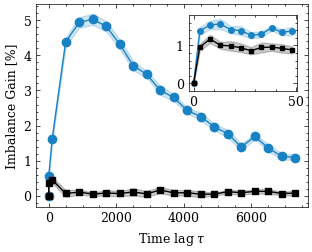

In [54]:
fig, ax1 = plt.subplots()

# x->y
ax1.plot(extended_taus, extended_IGs_X_to_Y, 'o-', color=colors[0])#, label="X")
ax1.fill_between(extended_taus, extended_IGs_X_to_Y - extended_errs_X_to_Y, extended_IGs_X_to_Y + extended_errs_X_to_Y, alpha=0.2, color=colors[0])
# y->x
ax1.plot(extended_taus, extended_IGs_Y_to_X, 's-', color=colors[1], markersize=5)#, label="Y")
ax1.fill_between(extended_taus, extended_IGs_Y_to_X - extended_errs_Y_to_X, extended_IGs_Y_to_X + extended_errs_Y_to_X, alpha=0.2, color=colors[1])
# labels

#inset
subsamples = np.arange(0,len(taus_small),2)
ax2 = fig.add_axes([0.56, 0.55, 0.31, 0.29])
# x->y
ax2.plot(taus_small[subsamples], IGs_X_to_Y_small[subsamples], 'o-', color=colors[0], markersize=4)
ax2.fill_between(taus_small[subsamples], IGs_X_to_Y_small[subsamples] - errs_X_to_Y_small[subsamples], 
                 IGs_X_to_Y_small[subsamples] + errs_X_to_Y_small[subsamples], alpha=0.2, color=colors[0])
# y->x
ax2.plot(taus_small[subsamples], IGs_Y_to_X_small[subsamples], 's-', color=colors[1], markersize=3)
ax2.fill_between(taus_small[subsamples], IGs_Y_to_X_small[subsamples] - errs_Y_to_X_small[subsamples], 
                 IGs_Y_to_X_small[subsamples] + errs_Y_to_X_small[subsamples], alpha=0.2, color=colors[1])
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
ax1.set(xlabel="Time lag $\\tau$", ylabel="Imbalance Gain [%]")
ax2.set(ylim=[-0.2,1.8])
plt.savefig(dir + '/figures_tau0/IG_3minima_inset.pdf', transparent=True, dpi=300)
plt.show()

## 2) Symmetric well, with nonzero cross correlation

### 2.1) Transfer entropy

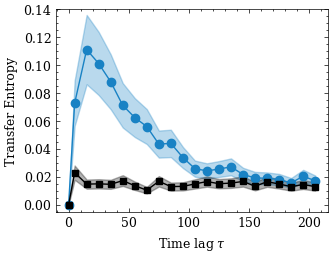

In [56]:
k = 7
taus = np.append([0], np.arange(5,215,10,dtype=int))
seeds = np.arange(20)

TEs_X_to_Y = np.zeros((len(seeds),len(taus)-1))
TEs_Y_to_X = np.zeros((len(seeds),len(taus)-1))

for iseed, seed in enumerate(seeds):
    _, TEs_X_to_Y[iseed], TEs_Y_to_X[iseed] = (
        pickle.load(open(f"{dir}/gaussian_skewed/pickles_te/seed{seed}_N{2500}_k{k}.p","rb"))
    )
# continuous
avg_X_to_Y, err_X_to_Y = TEs_X_to_Y.mean(axis=0), TEs_X_to_Y.mean(axis=0) / np.sqrt(TEs_X_to_Y.shape[0])
avg_Y_to_X, err_Y_to_X = TEs_Y_to_X.mean(axis=0), TEs_Y_to_X.mean(axis=0) / np.sqrt(TEs_Y_to_X.shape[0])
avg_X_to_Y = np.append([0],avg_X_to_Y)
avg_Y_to_X = np.append([0],avg_Y_to_X)
err_X_to_Y = np.append([0],err_X_to_Y)
err_Y_to_X = np.append([0],err_Y_to_X)

plt.plot(taus, avg_X_to_Y, 'o-', color=colors[0])
plt.plot(taus, avg_Y_to_X, 's-', color=colors[1], markersize=5)
plt.fill_between(taus, avg_X_to_Y-err_X_to_Y, avg_X_to_Y+err_X_to_Y, alpha=0.3, color=colors[0])
plt.fill_between(taus, avg_Y_to_X-err_Y_to_X, avg_Y_to_X+err_Y_to_X, alpha=0.3, color=colors[1])
#plt.hlines(0.0, taus[0], taus[-1], linestyle="--", color="black")
plt.xlabel("Time lag $\\tau$")
plt.ylabel("Transfer Entropy")
plt.ylim([-0.005, 0.140])
#plt.legend()
plt.savefig(f'{dir}/figures_tau0/TE_gaussian.pdf', transparent=True, dpi=300)
plt.show()

### 2.2) Imbalance Gain

In [60]:
k = 25
taus = np.append([0], np.arange(5,215,10,dtype=int))
seeds = np.arange(20)
alphas = np.linspace(0,1,300)
N = 2500
imbs_X_to_Y = np.zeros((len(seeds), len(taus)-1, len(alphas)))
imbs_Y_to_X = np.zeros((len(seeds), len(taus)-1, len(alphas)))

for seed in seeds:
    _, imbs_X_to_Y[seed], imbs_Y_to_X[seed] = pickle.load(open(f"{dir}/gaussian_skewed/pickles_imb/seed{seed}_N{N}_k{k}.p","rb"))

IGs_X_to_Y, errs_X_to_Y = compute_IGs(imbs_X_to_Y, correction=True)
IGs_Y_to_X, errs_Y_to_X = compute_IGs(imbs_Y_to_X, correction=True)

IGs_X_to_Y = np.append([0],IGs_X_to_Y)
IGs_Y_to_X = np.append([0],IGs_Y_to_X)
errs_X_to_Y = np.append([0],errs_X_to_Y)
errs_Y_to_X = np.append([0],errs_Y_to_X)

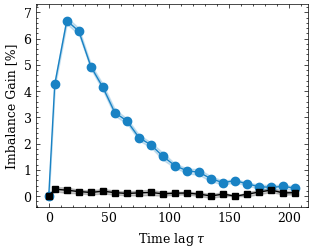

In [61]:
# x->y
plt.plot(taus, IGs_X_to_Y, 'o-', color=colors[0])
plt.fill_between(taus, IGs_X_to_Y - errs_X_to_Y, IGs_X_to_Y + errs_X_to_Y, alpha=0.2, color=colors[0])
# y->x
plt.plot(taus, IGs_Y_to_X, 's-', color=colors[1], markersize=5)
plt.fill_between(taus, IGs_Y_to_X - errs_Y_to_X, IGs_Y_to_X + errs_Y_to_X, alpha=0.2, color=colors[1])
# labels
#plt.xticks(taus)
plt.xlabel("Time lag $\\tau$")
plt.ylabel("Imbalance Gain [%]")
#plt.legend()
plt.ylim([-0.4,7.3])
plt.savefig(f'{dir}/figures_tau0/IG_gaussian.pdf', transparent=True, dpi=300)
plt.show()

### 2.3) Transfer entropy, no diff in autocorr

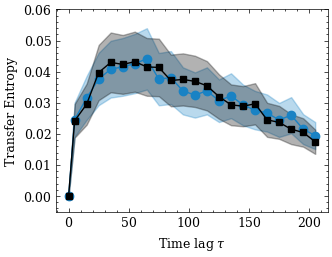

In [62]:
k = 7
taus = np.append([0], np.arange(5,215,10,dtype=int))
seeds = np.arange(20)

TEs_X_to_Y = np.zeros((len(seeds),len(taus)-1))
TEs_Y_to_X = np.zeros((len(seeds),len(taus)-1))

for iseed, seed in enumerate(seeds):
    _, TEs_X_to_Y[iseed], TEs_Y_to_X[iseed] = (
        pickle.load(open(f"/scratch/vdeltatt/imbalance-gain-causality/langevin/gaussian_skewed_nodiff/pickles_te/seed{seed}_N{2500}_k{k}.p","rb"))
    )
# continuous
avg_X_to_Y, err_X_to_Y = TEs_X_to_Y.mean(axis=0), TEs_X_to_Y.mean(axis=0) / np.sqrt(TEs_X_to_Y.shape[0])
avg_Y_to_X, err_Y_to_X = TEs_Y_to_X.mean(axis=0), TEs_Y_to_X.mean(axis=0) / np.sqrt(TEs_Y_to_X.shape[0])
avg_X_to_Y = np.append([0],avg_X_to_Y)
avg_Y_to_X = np.append([0],avg_Y_to_X)
err_X_to_Y = np.append([0],err_X_to_Y)
err_Y_to_X = np.append([0],err_Y_to_X)

plt.plot(taus, avg_X_to_Y, 'o-', color=colors[0])
plt.plot(taus, avg_Y_to_X, 's-', color=colors[1], markersize=5)
plt.fill_between(taus, avg_X_to_Y-err_X_to_Y, avg_X_to_Y+err_X_to_Y, alpha=0.3, color=colors[0])
plt.fill_between(taus, avg_Y_to_X-err_Y_to_X, avg_Y_to_X+err_Y_to_X, alpha=0.3, color=colors[1])
#plt.hlines(0.0, taus[0], taus[-1], linestyle="--", color="black")
plt.xlabel("Time lag $\\tau$")
plt.ylabel("Transfer Entropy")
plt.ylim([-0.005, 0.06])
#plt.legend()
plt.savefig('/scratch/vdeltatt/imbalance-gain-causality/langevin/figures_tau0/TE_gaussian_nodiff.pdf', transparent=True, dpi=300)
plt.show()

### 2.4) Imbalance Gain, no diff in autocorr

In [65]:
k = 25
taus = np.append([0], np.arange(5,215,10,dtype=int))
seeds = np.arange(20)
alphas = np.linspace(0,1,300)
N = 2500
imbs_X_to_Y = np.zeros((len(seeds), len(taus)-1, len(alphas)))
imbs_Y_to_X = np.zeros((len(seeds), len(taus)-1, len(alphas)))

for seed in seeds:
    _, imbs_X_to_Y[seed], imbs_Y_to_X[seed] = pickle.load(open(f"/scratch/vdeltatt/imbalance-gain-causality/langevin/gaussian_skewed_nodiff/pickles_imb/seed{seed}_N{N}_k{k}.p","rb"))

IGs_X_to_Y, errs_X_to_Y = compute_IGs(imbs_X_to_Y, correction=True)
IGs_Y_to_X, errs_Y_to_X = compute_IGs(imbs_Y_to_X, correction=True)

IGs_X_to_Y = np.append([0],IGs_X_to_Y)
IGs_Y_to_X = np.append([0],IGs_Y_to_X)
errs_X_to_Y = np.append([0],errs_X_to_Y)
errs_Y_to_X = np.append([0],errs_Y_to_X)

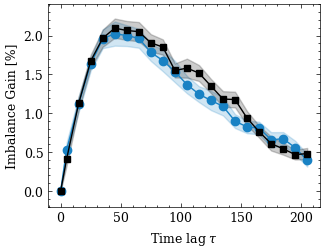

In [69]:
# x->y
plt.plot(taus, IGs_X_to_Y, 'o-', color=colors[0])
plt.fill_between(taus, IGs_X_to_Y - errs_X_to_Y, IGs_X_to_Y + errs_X_to_Y, alpha=0.2, color=colors[0])
# y->x
plt.plot(taus, IGs_Y_to_X, 's-', color=colors[1], markersize=5)
plt.fill_between(taus, IGs_Y_to_X - errs_Y_to_X, IGs_Y_to_X + errs_Y_to_X, alpha=0.2, color=colors[1])
# labels
#plt.xticks(taus)
plt.xlabel("Time lag $\\tau$")
plt.ylabel("Imbalance Gain [%]")
#plt.legend()
plt.ylim([-0.2,2.4])
plt.savefig('/scratch/vdeltatt/imbalance-gain-causality/langevin/figures_tau0/IG_gaussian_nodiff.pdf', transparent=True, dpi=300)
plt.show()

# 3) Markov system

### 3.1) Transfer entropy

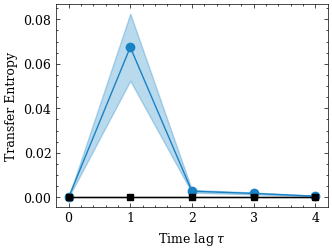

In [71]:
k = 7
taus, TEs_X_to_Y, TEs_Y_to_X = pickle.load(open("/scratch/vdeltatt/imbalance-gain-causality/markov/pickles_te/allseeds.p","rb"))
ntrajs = TEs_X_to_Y.shape[0]
taus = np.append([0],taus)

# continuous
avg_X_to_Y, err_X_to_Y = TEs_X_to_Y.mean(axis=0), TEs_X_to_Y.mean(axis=0) / np.sqrt(TEs_X_to_Y.shape[0])
avg_Y_to_X, err_Y_to_X = TEs_Y_to_X.mean(axis=0), TEs_Y_to_X.mean(axis=0) / np.sqrt(TEs_Y_to_X.shape[0])
avg_X_to_Y = np.append([0],avg_X_to_Y)
avg_Y_to_X = np.append([0],avg_Y_to_X)
err_X_to_Y = np.append([0],err_X_to_Y)
err_Y_to_X = np.append([0],err_Y_to_X)

last_lag = 5
plt.plot(taus[:last_lag], avg_X_to_Y[:last_lag], 'o-', color=colors[0])#, label="ref dipole $\\rightarrow $ 1st shell")
plt.plot(taus[:last_lag], avg_Y_to_X[:last_lag], 's-', color=colors[1], markersize=5)#, label="1st shell $\\rightarrow $ ref dipole")
plt.fill_between(taus[:last_lag], avg_X_to_Y[:last_lag]-err_X_to_Y[:last_lag], avg_X_to_Y[:last_lag]+err_X_to_Y[:last_lag], alpha=0.3, color=colors[0])
plt.fill_between(taus[:last_lag], avg_Y_to_X[:last_lag]-err_Y_to_X[:last_lag], avg_Y_to_X[:last_lag]+err_Y_to_X[:last_lag], alpha=0.3, color=colors[1])
#plt.hlines(0.0, taus[0], taus[last_lag-1], linestyle="--", color="black")
plt.xlabel("Time lag $\\tau$")
plt.ylabel("Transfer Entropy")
#plt.xlim([-5, 2000])
#plt.legend()
plt.savefig(f'{dir}/figures_tau0/TE_markov.pdf', transparent=True, dpi=300)
plt.show()

### 2.2) Imbalance Gain

In [73]:
k = 25
taus = np.append([0], np.arange(1,11,dtype=int))
seeds = np.arange(20)
alphas = np.linspace(0,20,500)
N = 2500
imbs_X_to_Y = np.zeros((len(seeds), len(taus)-1, len(alphas)))
imbs_Y_to_X = np.zeros((len(seeds), len(taus)-1, len(alphas)))

for seed in seeds:
    _, alphas, imbs_X_to_Y[seed], imbs_Y_to_X[seed] = pickle.load(open(f"/scratch/vdeltatt/imbalance-gain-causality/markov/pickles_ig/seed{seed}_k{k}.p","rb"))

IGs_X_to_Y, errs_X_to_Y = compute_IGs(imbs_X_to_Y, correction=True)
IGs_Y_to_X, errs_Y_to_X = compute_IGs(imbs_Y_to_X, correction=True)

IGs_X_to_Y = np.append([0],IGs_X_to_Y)
IGs_Y_to_X = np.append([0],IGs_Y_to_X)
errs_X_to_Y = np.append([0],errs_X_to_Y)
errs_Y_to_X = np.append([0],errs_Y_to_X)

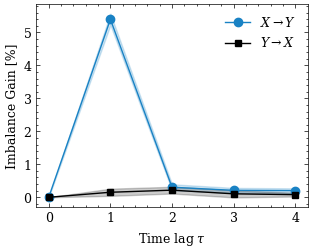

In [74]:
last_lag = 5

# x->y
plt.plot(taus[:last_lag], IGs_X_to_Y[:last_lag], 'o-', label="$X \\rightarrow Y$", color=colors[0])
plt.fill_between(taus[:last_lag], IGs_X_to_Y[:last_lag] - errs_X_to_Y[:last_lag], IGs_X_to_Y[:last_lag] + errs_X_to_Y[:last_lag], alpha=0.2, color=colors[0])
# y->x
plt.plot(taus[:last_lag], IGs_Y_to_X[:last_lag], 's-', label="$Y \\rightarrow X$", color=colors[1], markersize=5)
plt.fill_between(taus[:last_lag], IGs_Y_to_X[:last_lag] - errs_Y_to_X[:last_lag], IGs_Y_to_X[:last_lag] + errs_Y_to_X[:last_lag], alpha=0.2, color=colors[1])
# labels
#plt.xticks(taus)
plt.xlabel("Time lag $\\tau$")
plt.ylabel("Imbalance Gain [%]")
plt.legend()
plt.savefig(f'{dir}/figures_tau0/IG_markov.pdf', transparent=True, dpi=300)
plt.show()